    # Cattle Average Daily Gain Prediction with a Deep Neural Network

Estimate **average daily gain (ADG, kg/day)** from the `cattle_dataset.csv` dataset.

target variable: `adg_kg_day`.

# 1. Ambient configuration

## 1.1. Import packages

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

## 1.2. GPU check

In [19]:
if torch.cuda.is_available():
    print("__CUDNN VERSION:", torch.backends.cudnn.version())
    print("Device Name:", torch.cuda.get_device_name(0))
    device = 'cuda'
else:
    print("CUDA is not available.")
    device = 'cpu'

print('Device:', device)

__CUDNN VERSION: 92000
Device Name: NVIDIA GeForce RTX 5070
Device: cuda


# 2. Exploratory Data Analysis

## 2.1. Load data

In [20]:
DATA_PATH = "data/cattle_dataset_2.csv"
TARGET = "adg_kg_day"
LEAKAGE = "days_on_pasture" 

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

df = pd.read_csv(DATA_PATH)
if "origem" in df.columns:           # drop tag column if present
    df = df.drop(columns=["origem"])
df.head()

,initial_weight_kg,age_days,sex_male,bos_indicus_proportion_pct,supplement_amount_kg_day,supplement_crude_protein_pct,supplement_metabolizable_energy,supplementation_frequency_days_week,forage_crude_protein_pct,forage_digestibility_pct,days_on_pasture,paddock_rotation,transport_stress,mean_temperature_c,accumulated_rainfall_mm,days_since_health_event,health_event_duration_days,recent_vaccination,recent_deworming,adg_kg_day
0,185,620,0,50.0,0.248,30,2.0,7,10.42,61.2,381,1,1,29.0,47.8,0,0,0,0,0.330709
1,168,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.328889
2,153,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.317778
3,130,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.468889
4,156,620,0,50.0,0.248,30,2.0,7,10.42,61.2,450,1,1,29.0,47.8,0,0,0,0,0.342222


In [21]:
const_cols = [c for c in df.columns if df[c].nunique() == 1]
num_cols = [c for c in df.select_dtypes("number").columns if c not in const_cols]
bin_cols = [c for c in num_cols if set(df[c].dropna().unique()) <= {0, 1}]
cat_cols = [c for c in num_cols
            if c not in bin_cols and c != TARGET and df[c].nunique() <= 6]
cont_cols = [c for c in num_cols
             if c not in bin_cols and c not in cat_cols and c != TARGET]

print("Constant :", const_cols)
print("Continuous:", cont_cols)
print("Categorical:", cat_cols)
print("Binary   :", bin_cols)

Constant : ['sex_male', 'supplementation_frequency_days_week', 'paddock_rotation', 'recent_vaccination', 'recent_deworming']
Continuous: ['initial_weight_kg', 'age_days', 'supplement_amount_kg_day', 'days_on_pasture', 'mean_temperature_c', 'accumulated_rainfall_mm']
Categorical: ['bos_indicus_proportion_pct', 'supplement_crude_protein_pct', 'supplement_metabolizable_energy', 'forage_crude_protein_pct', 'forage_digestibility_pct', 'days_since_health_event', 'health_event_duration_days']
Binary   : ['transport_stress']


## 2.2. Overview

In [22]:
print(f"Samples: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(),
    "missing": df.isna().sum(),
})
overview

Samples: 494
Variables: 20


,dtype,unique,missing
initial_weight_kg,int64,183,0
age_days,int64,127,0
sex_male,int64,1,0
bos_indicus_proportion_pct,float64,4,0
supplement_amount_kg_day,float64,309,0
supplement_crude_protein_pct,int64,2,0
supplement_metabolizable_energy,float64,3,0
supplementation_frequency_days_week,int64,1,0
forage_crude_protein_pct,float64,6,0
forage_digestibility_pct,float64,6,0


## 2.3. Target variable distribution

count    494.000
mean       0.341
std        0.171
min       -0.698
25%        0.284
50%        0.345
75%        0.412
max        1.785
skewness: 1.16


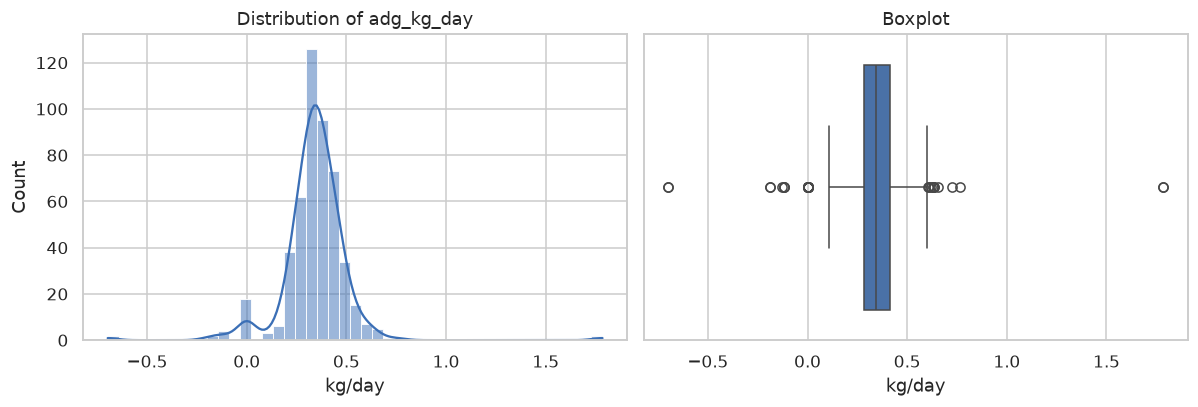

In [23]:
print(df[TARGET].describe().round(3).to_string())
print(f"skewness: {df[TARGET].skew():.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
sns.histplot(df[TARGET], kde=True, ax=ax[0], color="#3b6fb6")
ax[0].set_title(f"Distribution of {TARGET}"); ax[0].set_xlabel("kg/day")
sns.boxplot(x=df[TARGET], ax=ax[1], color="#3b6fb6")
ax[1].set_title("Boxplot"); ax[1].set_xlabel("kg/day")
plt.tight_layout(); plt.show()

## 2.4. Distributions of continuous variables

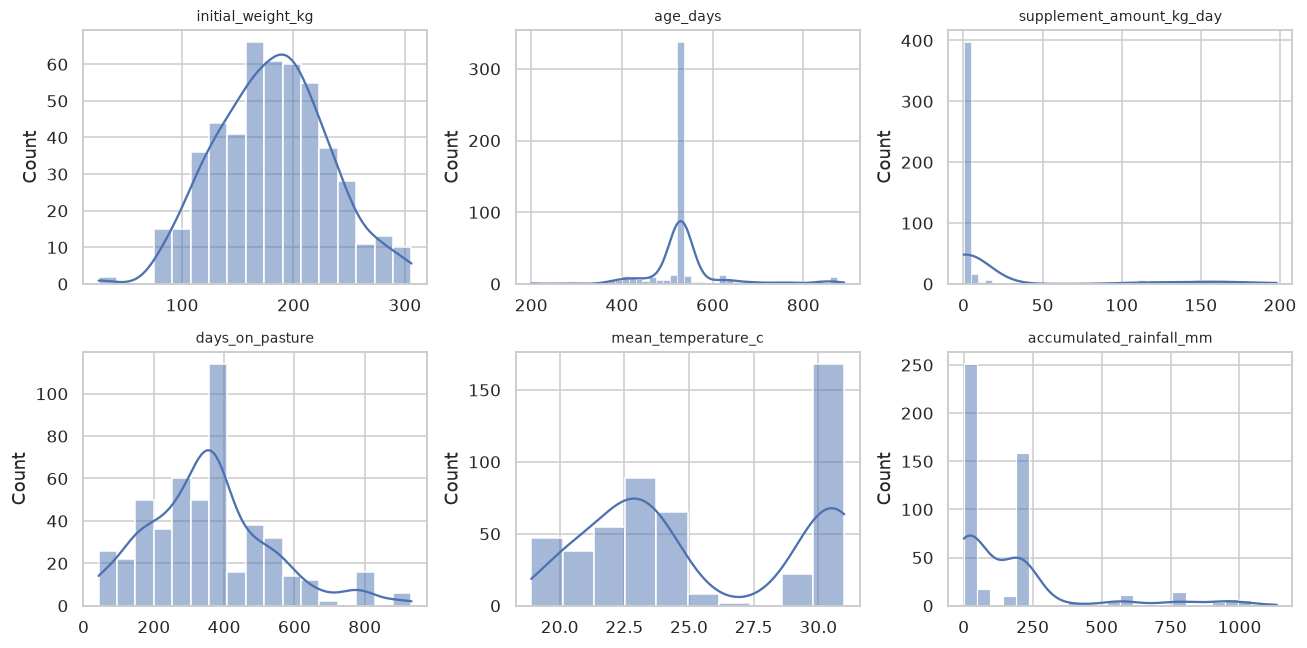

In [24]:
n = len(cont_cols); ncol = 3; nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3 * nrow))
axes = np.array(axes).reshape(-1)
for i, c in enumerate(cont_cols):
    sns.histplot(df[c], kde=True, ax=axes[i])
    axes[i].set_title(c, fontsize=9); axes[i].set_xlabel("")
for j in range(n, len(axes)):
    axes[j].axis("off")
plt.tight_layout(); plt.show()

## 2.5. Correlation matrix

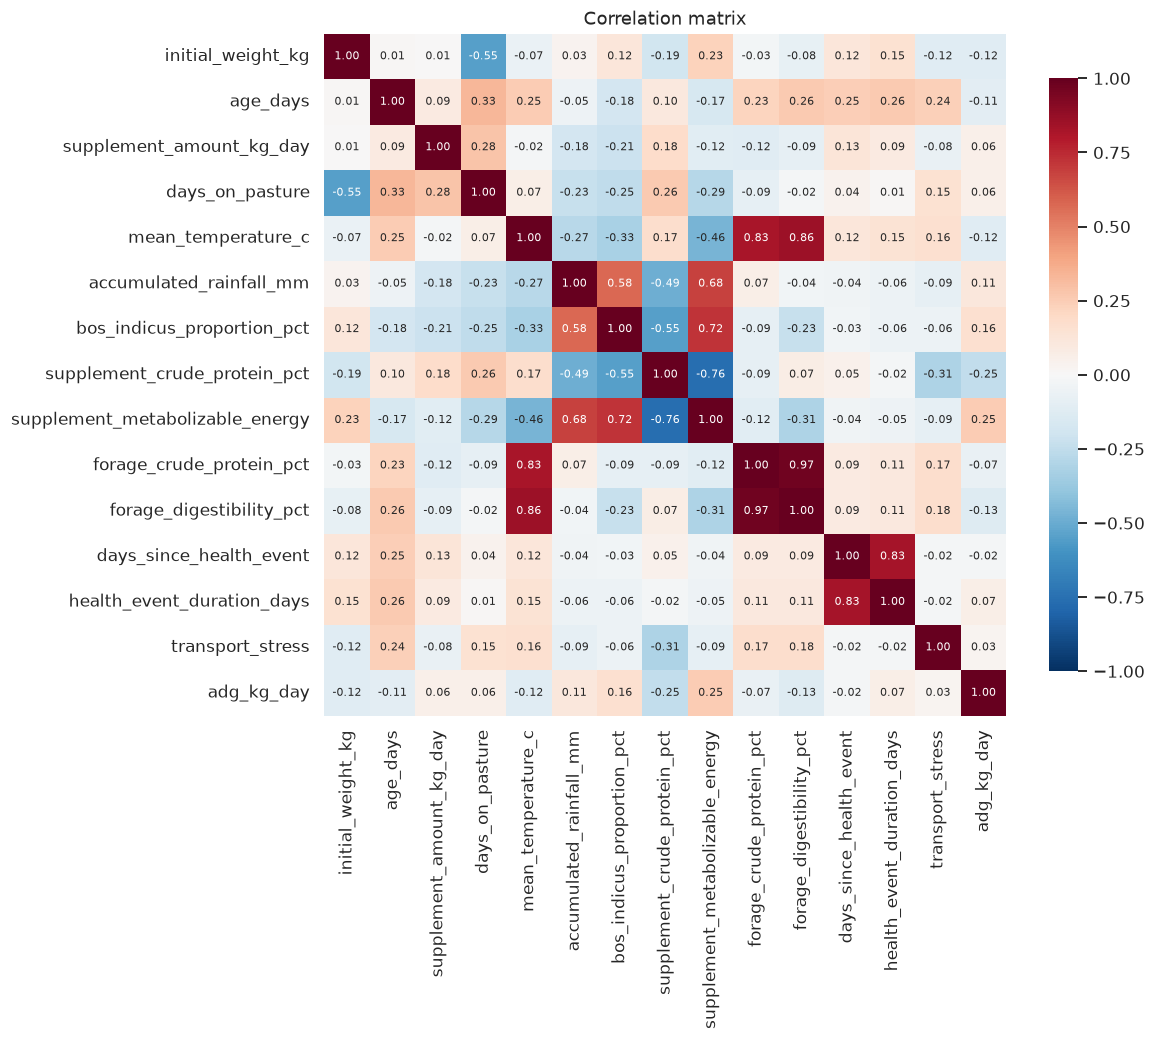

In [25]:
corr_cols = cont_cols + cat_cols + bin_cols + [TARGET]
corr = df[corr_cols].corr()
size = min(1 + 0.6 * len(corr_cols), 13)
fig, ax = plt.subplots(figsize=(size, size))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"shrink": .7},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation matrix"); plt.show()

## 2.6. Correlation with the target

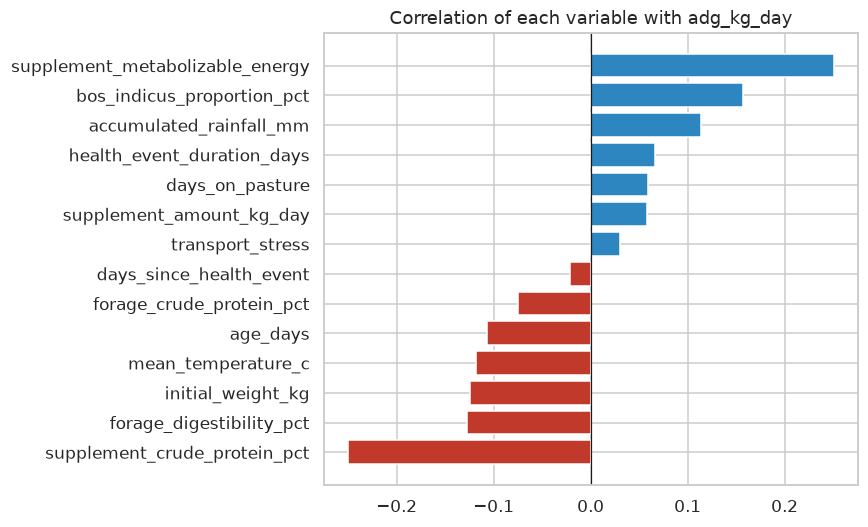

In [26]:
corr_target = corr[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(corr_target))))
colors = ["#c0392b" if v < 0 else "#2e86c1" for v in corr_target.values]
ax.barh(corr_target.index, corr_target.values, color=colors)
ax.axvline(0, color="k", lw=.8)
ax.set_title(f"Correlation of each variable with {TARGET}")
plt.tight_layout(); plt.show()

if LEAKAGE in corr_target.index:
    print(f"WARNING: '{LEAKAGE}' is the denominator of the ADG formula "
          f"(spurious correlation / leakage). Keep it out of the model predictors.")